In [1]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, math, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(SEED)

# Tự động phát hiện GPU nếu có
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
DATA_PATH = r"C:\Users\ADMIN\Desktop\Dữ Liệu\IDS2018-v2\NF-CSE-CIC-IDS2018-V2.parquet"
LABEL_COL   = 'Label'
N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 0
EPOCHS      = 13        
LR          = 3e-4       
D_MODEL     = 128         
N_HEADS     = 8
N_PERSIST   = 6
LMM_HIDDEN  = 128        
OUTLIER_TH  = 3.0
PRE_BATCH   = 50000
SWA_WINDOW  = 16
LMM_LAYERS  = 3           
HEAD_DROPOUT = 0.2        
LMM_DROPOUT  = 0.15

WARMUP_EPOCHS = 2         

FOCAL_GAMMA = 2.0         

N_APT_PHASES = 15

## 1. Load parquet + xử lý cột constant & log transform

In [4]:
df = pd.read_parquet(DATA_PATH)
print('Raw shape:', df.shape)

std_series = df.std(numeric_only=True)
const_cols = std_series[std_series == 0].index.tolist()
print('Cột số constant:', const_cols)

if 'SRC_TO_DST_SECOND_BYTES' in df.columns:
    df['SRC_TO_DST_SECOND_BYTES_LOG'] = np.log1p(df['SRC_TO_DST_SECOND_BYTES'])
    df = df.drop(columns=['SRC_TO_DST_SECOND_BYTES'])


LABEL_MULTI = 'Attack' if 'Attack' in df.columns else 'Label'

drop_cols = [c for c in ['Label', 'Attack'] + const_cols if c in df.columns]
numerical_columns = [c for c in df.columns
                     if c not in drop_cols and np.issubdtype(df[c].dtype, np.number)]

X = df[numerical_columns].copy()
attack_raw = df[LABEL_MULTI].astype(str).fillna('Benign').values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(attack_raw).astype(np.int64)
CLASS_NAMES = list(label_encoder.classes_)
N_APT_PHASES = len(CLASS_NAMES)

for i, name in enumerate(CLASS_NAMES):
    cnt = int((y == i).sum())
    print(f'  {i:2d} - {name}: {cnt:,}')

Raw shape: (17129715, 43)
Cột số constant: ['FTP_COMMAND_RET_CODE']
   0 - Benign: 15,101,685
   1 - Bot: 28,033
   2 - Brute Force -Web: 2,143
   3 - Brute Force -XSS: 927
   4 - DDOS attack-HOIC: 1,066,881
   5 - DDOS attack-LOIC-UDP: 2,112
   6 - DDoS attacks-LOIC-HTTP: 207,078
   7 - DoS attacks-GoldenEye: 27,723
   8 - DoS attacks-Hulk: 432,648
   9 - DoS attacks-SlowHTTPTest: 14,116
  10 - DoS attacks-Slowloris: 9,512
  11 - FTP-BruteForce: 25,933
  12 - Infilteration: 115,513
  13 - SQL Injection: 432
  14 - SSH-Bruteforce: 94,979


## 2. Split train / val / test (stratified)

In [5]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
del X, X_tmp, y_tmp, df; gc.collect()

20

## 3. Robust preprocessing theo batch (NaN / Inf / Outlier)

In [6]:
def robust_clean(X_tr, X_val, X_te, batch=50_000, th=3.0):
    
    if hasattr(X_tr, 'values'): X_tr = X_tr.values
    if hasattr(X_val, 'values'): X_val = X_val.values
    if hasattr(X_te, 'values'): X_te = X_te.values
        
    X_tr  = X_tr.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_te  = X_te.astype(np.float32)

    s = min(100_000, len(X_tr))
    idx = np.random.choice(len(X_tr), s, replace=False)
    med = np.nanmedian(X_tr[idx], axis=0)
    std = np.nanstd(X_tr[idx],    axis=0); std[std==0] = 1.0

    def clean(A):
        out = []
        for i in range(0, len(A), batch):
            B = A[i:i+batch].copy()
            B[np.isinf(B)] = np.nan
            for c in range(B.shape[1]):
                m = med[c]
                bad = np.isnan(B[:,c]) | (np.abs((B[:,c]-m)/std[c]) > th)
                B[bad, c] = m
            out.append(np.clip(B, -1e6, 1e6))
        return np.vstack(out)

    Xtr, Xva, Xte = clean(X_tr), clean(X_val), clean(X_te)
    return Xtr, Xva, Xte


X_tr, X_val, X_te = robust_clean(X_tr, X_val, X_te, PRE_BATCH, OUTLIER_TH)

nc = min(N_PCA, X_tr.shape[1])
pca = PCA(n_components=nc, random_state=SEED)
X_tr  = pca.fit_transform(X_tr)
X_val = pca.transform(X_val)
X_te  = pca.transform(X_te)

sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te  = sc.transform(X_te)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr).astype(np.int64)
tok_val = kbd.transform(X_val).astype(np.int64)
tok_te  = kbd.transform(X_te).astype(np.int64)

vocab = [int(max(tok_tr[:,i].max(), tok_val[:,i].max(), tok_te[:,i].max())) + 2
         for i in range(tok_tr.shape[1])]
SEQ_LEN = tok_tr.shape[1]

## 6. Dataset & DataLoader

In [7]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=0, pin_memory=False)
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)

## 7. Kien truc TitanMAG v3 (RoPE + AWA)

In [8]:
ROPE_BASE = 1000.0   

def build_rope_cache(seq_len, inv_freq, device):
    t = torch.arange(seq_len, device=device).float()
    angles = torch.outer(t, inv_freq.to(device))          
    cos = angles.cos().repeat_interleave(2, dim=-1)
    sin = angles.sin().repeat_interleave(2, dim=-1)
    return cos, sin

def apply_rope(x, cos, sin):
    cos = cos.unsqueeze(0).unsqueeze(2)   
    sin = sin.unsqueeze(0).unsqueeze(2)   
    x1 = x[..., 0::2]; x2 = x[..., 1::2]
    x_rot = torch.stack((-x2, x1), dim=-1).flatten(-2)
    return x * cos + x_rot * sin


class Adaptive_Weighting_Attention(nn.Module):
    def __init__(self, d_model, n_heads, d_head, R):
        super().__init__()
        assert R >= 1 and n_heads >= 1 and d_head >= 1
        self.R, self.h, self.dh = R, n_heads, d_head
        self.A = nn.Linear(d_model, R * n_heads, bias=False)
        self.B = nn.Linear(d_model, R * d_head,  bias=False)
        nn.init.xavier_uniform_(self.A.weight)
        nn.init.xavier_uniform_(self.B.weight)

        self.alpha = nn.Parameter(torch.ones(R, n_heads))

    def forward(self, x):                       
        B, L, _ = x.shape
        a = self.A(x).view(B, L, self.R, self.h)    
        b = self.B(x).view(B, L, self.R, self.dh)   

        a = a * self.alpha.view(1, 1, self.R, self.h)

        out = torch.einsum('blrh,blrd->blhd', a, b) / float(self.R)
        return out                              


class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight    = weight
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        p_t     = torch.exp(-ce_loss)
        focal   = (1.0 - p_t) ** self.gamma * ce_loss
        if self.reduction == 'mean': return focal.mean()
        if self.reduction == 'sum':  return focal.sum()
        return focal


class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d)
        self.norm = nn.LayerNorm(d)

    def forward(self, x):
        B, L = x.shape
        h = torch.stack([self.embs[i](x[:,i]) for i in range(L)], dim=1)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))


class NeuralLongTermMemory(nn.Module):

    def __init__(self, d, n_heads=8, lmm_r_q=2, lmm_r_k=2, lmm_r_v=2,
                 num_blocks=3, dropout=0.15):
        super().__init__()
        assert d % n_heads == 0
        self.h  = n_heads
        self.dh = d // n_heads

        self.tpa_q = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_q)
        self.tpa_k = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_k)
        self.tpa_v = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_v)

        half = self.dh // 2
        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, half * 2, 2).float() / (half * 2)))
        self.register_buffer('inv_freq', inv_freq)

        hidden = d * 4 // 3
        self.M_blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d),
                'fc1':  nn.Linear(d, hidden),
                'act':  nn.GELU(),
                'drop': nn.Dropout(dropout),
                'fc2':  nn.Linear(hidden, d),
            }) for _ in range(num_blocks)
        ])
        self.M_norm = nn.LayerNorm(d)

        self.alpha = nn.Linear(d, 1)
        self.eta   = nn.Linear(d, 1)
        self.theta = nn.Linear(d, 1)

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)

    def _M(self, x):
        for b in self.M_blocks:
            h = b['norm'](x)
            h = b['fc2'](b['drop'](b['act'](b['fc1'](h))))
            x = x + h
        return self.M_norm(x)

    def forward(self, h):
        B, L, D = h.shape

        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

        cos, sin = build_rope_cache(L, self.inv_freq, h.device)   
        q = apply_rope(q, cos, sin)   
        k = apply_rope(k, cos, sin)

        q_flat = q.reshape(B, L, D)
        k_flat = k.reshape(B, L, D)
        v_flat = v.reshape(B, L, D)

        a = torch.sigmoid(self.alpha(h))   
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1

        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for i in range(L):
            v_hat = self._M(k_flat[:, i]) + Mt
            St    = e[:, i] * St - t[:, i] * 2 * (v_hat - v_flat[:, i])
            Mt    = (1 - a[:, i]) * Mt + St
            outs.append(self.out_proj(self._M(q_flat[:, i]) + Mt))
        return self.norm(torch.stack(outs, dim=1))


class SlidingWindowAttention(nn.Module):
    def __init__(self, d, n_heads, window=16,
                 swa_r_q=2, swa_r_k=2, swa_r_v=2):
        super().__init__()
        assert d % n_heads == 0
        self.h      = n_heads
        self.dh     = d // n_heads
        self.window = window
        self.scale  = self.dh ** -0.5

        self.tpa_q = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_q)
        self.tpa_k = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_k)
        self.tpa_v = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_v)

        half = self.dh // 2
        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, half * 2, 2).float() / (half * 2)))
        self.register_buffer('inv_freq', inv_freq)

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)   

    def forward(self, x):                 
        B, L, D = x.shape

        h = self.norm(x)

        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

        cos, sin = build_rope_cache(L, self.inv_freq, x.device)
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        idx  = torch.arange(L, device=x.device)
        diff = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (diff > 0) | (diff < -(self.window - 1))
        mask = mask.unsqueeze(0).unsqueeze(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(mask, float('-inf'))
        attn = F.softmax(attn, dim=-1)

        out = attn @ v                                   
        out = out.permute(0, 2, 1, 3).reshape(B, L, D)  
        return x + self.out_proj(out)


class TitanMAG(nn.Module):
    def __init__(self, vocab_sizes, n_classes,
                 d=256, n_heads=8, n_persist=4, swa_window=16,
                 lmm_blocks=3, lmm_dropout=0.15, head_dropout=0.2,
                 r_q=2, r_k=2, r_v=2):
        super().__init__()
        self.embed  = FeatureEmbedding(vocab_sizes, d)
        self.P      = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)

        self.swa = SlidingWindowAttention(d, n_heads, swa_window,
                                          swa_r_q=r_q, swa_r_k=r_k, swa_r_v=r_v)
        self.lmm = NeuralLongTermMemory(d, n_heads,
                                         lmm_r_q=r_q, lmm_r_k=r_k, lmm_r_v=r_v,
                                         num_blocks=lmm_blocks, dropout=lmm_dropout)

        self.merge     = nn.Linear(d * 2, d)
        self.gate      = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)

        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d * 2),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(d * 2, d),
            nn.GELU(),
            nn.Dropout(head_dropout / 2),
            nn.Linear(d, n_classes)
        )
        self.np = n_persist

    def forward(self, x):
        B  = x.size(0)
        h  = self.embed(x)
        xt = torch.cat([self.P.expand(B, -1, -1), h], dim=1)

        y_swa = self.swa(xt)
        y_lmm = self.lmm(xt)

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1))
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt)))
        out = out[:, self.np:].mean(dim=1)
        return self.head(out)


TPA_R_Q = 2
TPA_R_K = 2
TPA_R_V = 2

model = TitanMAG(vocab, N_APT_PHASES,
                 d=D_MODEL, n_heads=N_HEADS, n_persist=N_PERSIST,
                 swa_window=SWA_WINDOW,
                 lmm_blocks=LMM_LAYERS, lmm_dropout=LMM_DROPOUT,
                 head_dropout=HEAD_DROPOUT,
                 r_q=TPA_R_Q, r_k=TPA_R_K, r_v=TPA_R_V).to(DEVICE)

total = sum(p.numel() for p in model.parameters())


## 8. Train (Focal Loss + Log-Smoothed Weights + LR Warmup)

In [9]:
def run_eval(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).argmax(-1).cpu().numpy())
            trues.append(yb.numpy())
    p, t = np.concatenate(preds), np.concatenate(trues)
    return dict(
        acc  = accuracy_score(t, p),
        f1   = f1_score(t, p, average='weighted', zero_division=0),
        prec = precision_score(t, p, average='weighted', zero_division=0),
        rec  = recall_score(t, p, average='weighted', zero_division=0),
        pred = p, true = t
    )

class_counts = np.bincount(y_tr, minlength=N_APT_PHASES)
smoothed = np.log1p(class_counts.astype(np.float64))          
smoothed_weights = smoothed.max() / np.maximum(smoothed, 1e-6) 
weights = torch.tensor(smoothed_weights, dtype=torch.float32, device=DEVICE)

for i, (n, w) in enumerate(zip(CLASS_NAMES, smoothed_weights)):
    print(f'  [{i:2d}] {n}: count={class_counts[i]:>10,} | weight={w:.3f}')

criterion = FocalLoss(weight=weights, gamma=FOCAL_GAMMA)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=LR * 0.01
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)


history = []
best_f1 = 0.0
best_state = None

for ep in range(1, EPOCHS + 1):
    model.train()
    losses = []
    current_lr = optimizer.param_groups[0]['lr']
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    m = run_eval(model, val_loader)
    avg_loss = np.mean(losses)
    history.append({'ep': ep, 'loss': avg_loss, **{k: m[k] for k in ['acc','f1','prec','rec']}})
    print(f'[Epoch {ep:2d}/{EPOCHS}] lr={current_lr:.2e} | loss={avg_loss:.4f} | '
          f'acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | prec={m["prec"]:.4f} | rec={m["rec"]:.4f}')

    # ✅ Best model checkpoint
    if m['f1'] > best_f1:
        best_f1 = m['f1']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'  ↑ Best F1 updated: {best_f1:.4f}')

# Load best weights
if best_state is not None:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})


  [ 0] Benign: count=10,571,179 | weight=1.000
  [ 1] Bot: count=    19,623 | weight=1.636
  [ 2] Brute Force -Web: count=     1,500 | weight=2.211
  [ 3] Brute Force -XSS: count=       649 | weight=2.497
  [ 4] DDOS attack-HOIC: count=   746,817 | weight=1.196
  [ 5] DDOS attack-LOIC-UDP: count=     1,478 | weight=2.216
  [ 6] DDoS attacks-LOIC-HTTP: count=   144,955 | weight=1.361
  [ 7] DoS attacks-GoldenEye: count=    19,406 | weight=1.638
  [ 8] DoS attacks-Hulk: count=   302,854 | weight=1.281
  [ 9] DoS attacks-SlowHTTPTest: count=     9,881 | weight=1.758
  [10] DoS attacks-Slowloris: count=     6,658 | weight=1.837
  [11] FTP-BruteForce: count=    18,153 | weight=1.649
  [12] Infilteration: count=    80,859 | weight=1.431
  [13] SQL Injection: count=       303 | weight=2.829
  [14] SSH-Bruteforce: count=    66,485 | weight=1.456
[Epoch  1/13] lr=3.00e-05 | loss=0.0465 | acc=0.9939 | f1=0.9921 | prec=0.9937 | rec=0.9939
  ↑ Best F1 updated: 0.9921
[Epoch  2/13] lr=1.65e-04 | lo

## 10. Đánh giá trên tập TEST + Confusion Matrix


===== TEST METRICS  =====
Accuracy        : 0.9948
F1  (weighted)  : 0.9935
F1  (macro)     : 0.7959
Precision (w)   : 0.9944
Recall    (w)   : 0.9948

                          precision    recall  f1-score   support

                  Benign       0.99      1.00      1.00   3020338
                     Bot       1.00      1.00      1.00      5607
        Brute Force -Web       0.82      0.12      0.21       429
        Brute Force -XSS       0.78      0.15      0.25       185
        DDOS attack-HOIC       1.00      1.00      1.00    213376
    DDOS attack-LOIC-UDP       0.98      0.99      0.99       422
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     41415
   DoS attacks-GoldenEye       0.99      0.99      0.99      5545
        DoS attacks-Hulk       1.00      1.00      1.00     86529
DoS attacks-SlowHTTPTest       1.00      1.00      1.00      2823
   DoS attacks-Slowloris       0.94      1.00      0.97      1903
          FTP-BruteForce       1.00      1.00      1.0

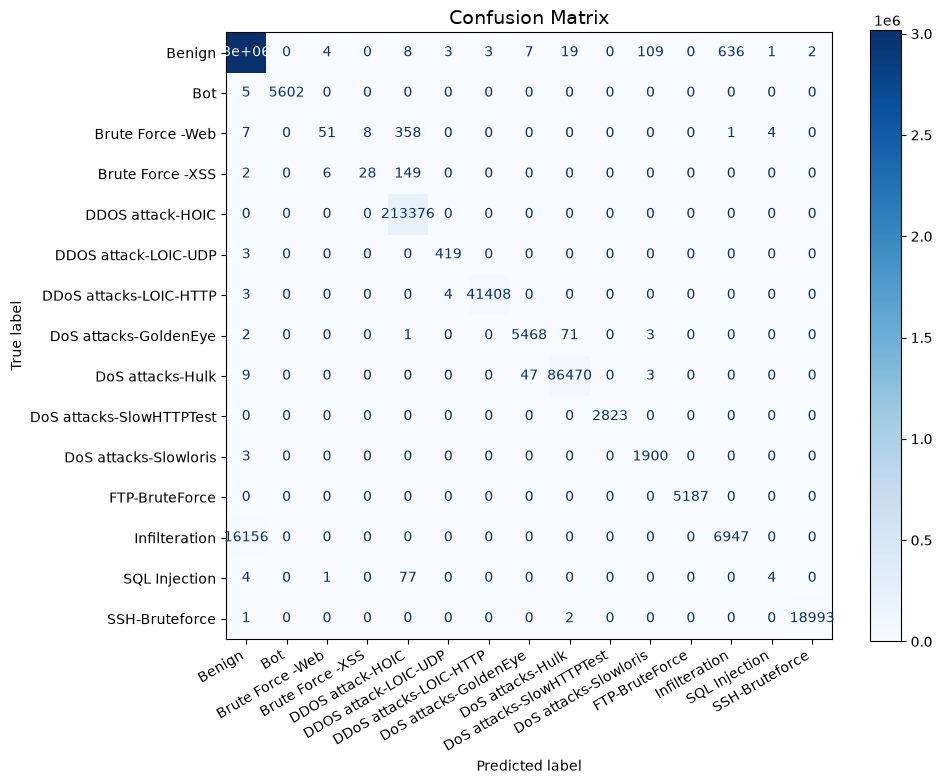

In [10]:
m = run_eval(model, test_loader)
APT_PHASE_NAMES = CLASS_NAMES

print('\n===== TEST METRICS  =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1  (weighted)  : {m["f1"]:.4f}')
print(f'F1  (macro)     : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall    (w)   : {m["rec"]:.4f}')
print()
print(classification_report(m['true'], m['pred'],
                             target_names=APT_PHASE_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=APT_PHASE_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()

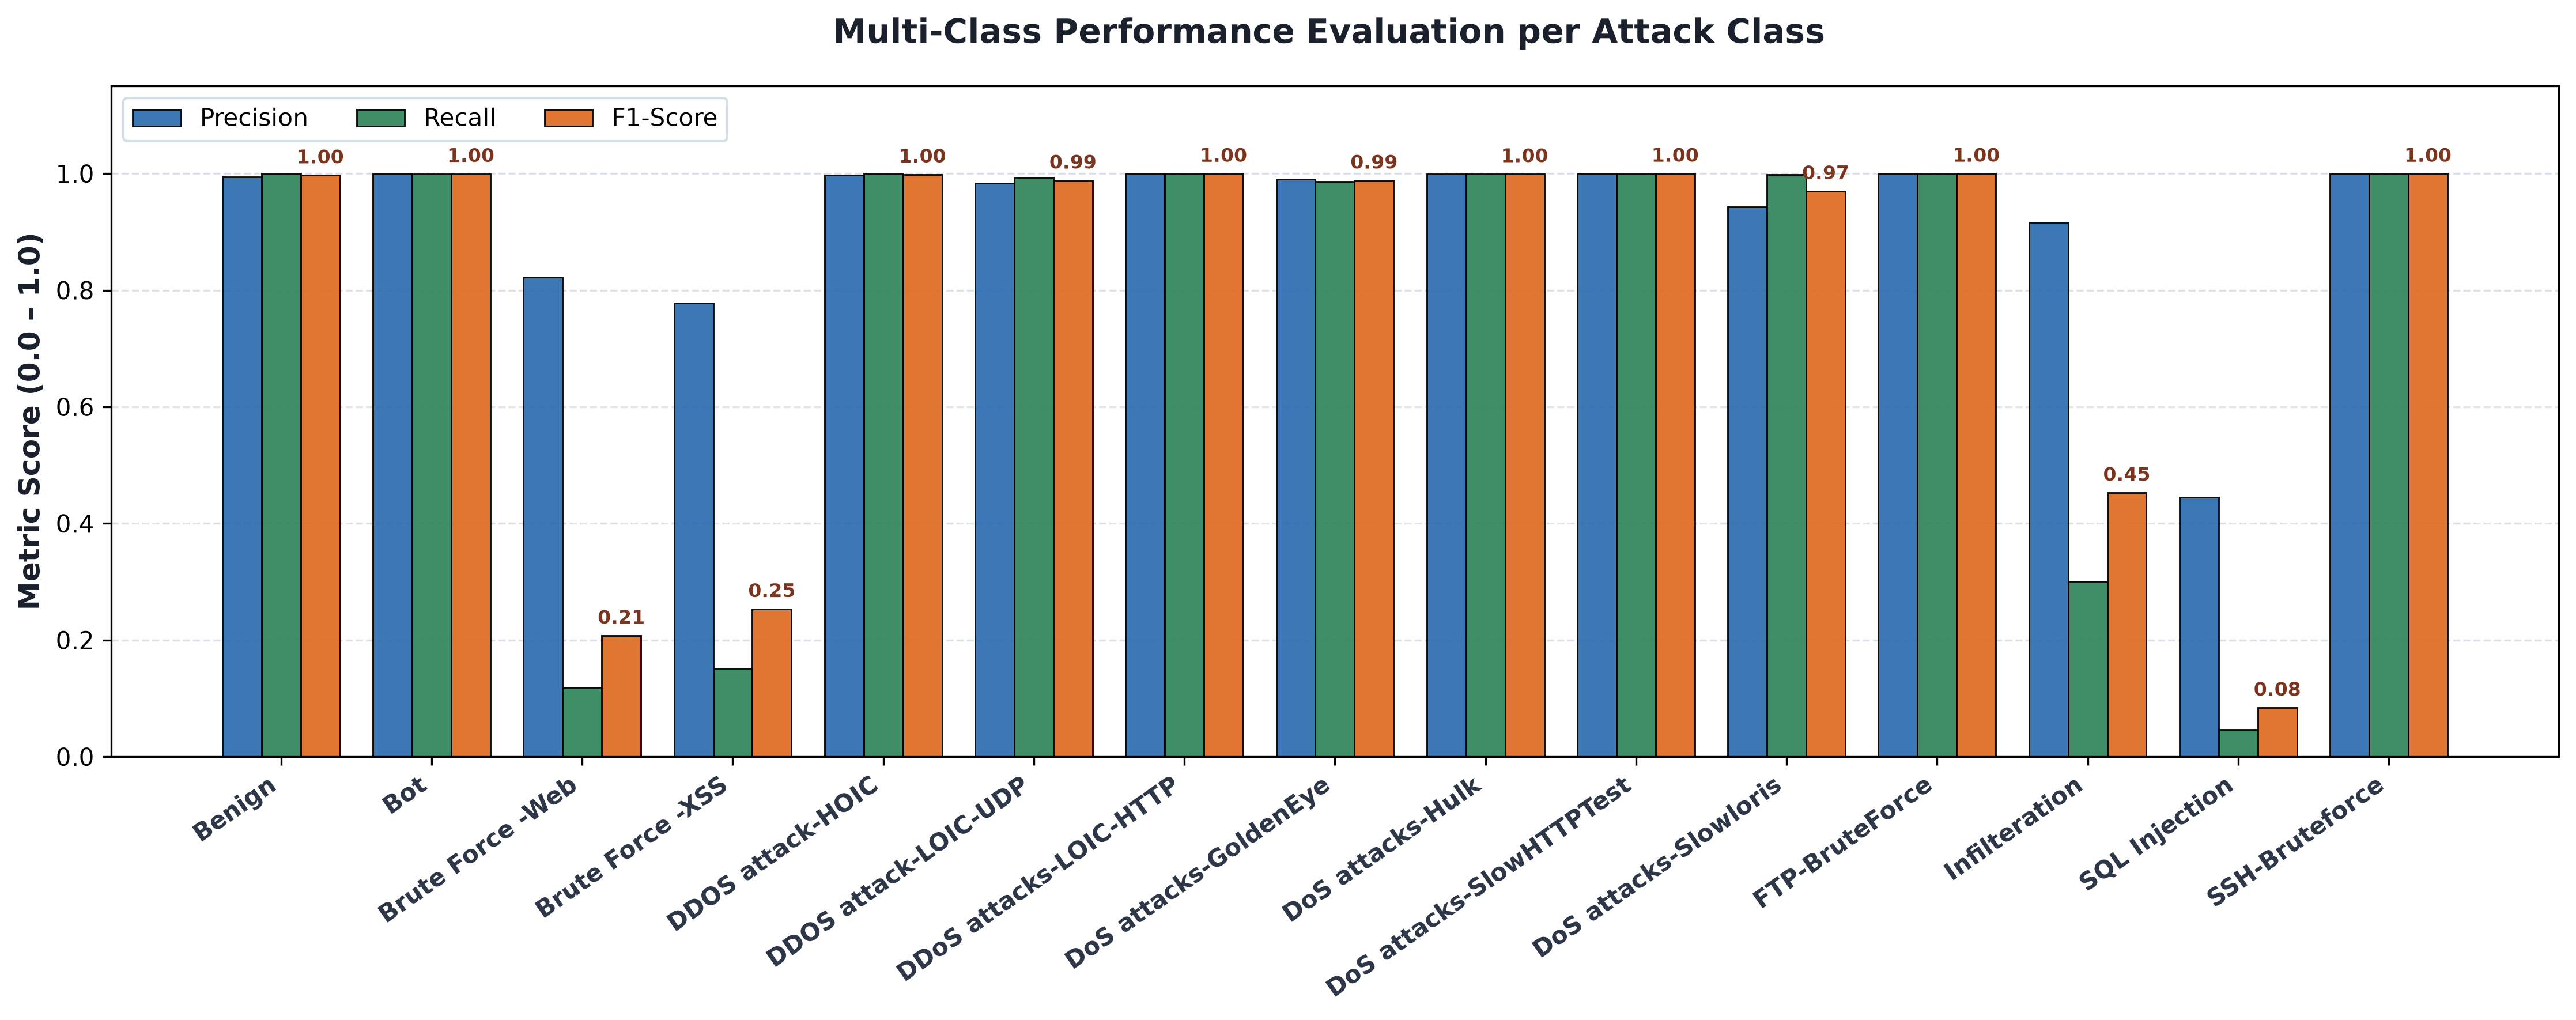

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# 1. Tính toán metrics từ m['true'] và m['pred']
report = classification_report(
    m['true'], 
    m['pred'], 
    target_names=CLASS_NAMES, 
    output_dict=True, 
    zero_division=0
)
df_rep = pd.DataFrame(report).transpose().iloc[:-3]  # Bỏ qua micro, macro, weighted avg

classes   = df_rep.index.tolist()
precision = df_rep['precision'].values
recall    = df_rep['recall'].values
f1        = df_rep['f1-score'].values

x = np.arange(len(classes))
bar_width = 0.26

# 2. Khởi tạo Figure chuẩn High-DPI
fig, ax = plt.subplots(figsize=(15, 6), dpi=300)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Vẽ 3 cột Precision, Recall, F1-Score
rects1 = ax.bar(x - bar_width, precision, bar_width, label='Precision', 
                color='#2B6CB0', alpha=0.92, edgecolor='black', linewidth=0.7)
rects2 = ax.bar(x, recall, bar_width, label='Recall', 
                color='#2F855A', alpha=0.92, edgecolor='black', linewidth=0.7)
rects3 = ax.bar(x + bar_width, f1, bar_width, label='F1-Score', 
                color='#DD6B20', alpha=0.92, edgecolor='black', linewidth=0.7)

# Cấu hình trục Y và X
ax.set_ylabel('Metric Score (0.0 – 1.0)', fontsize=12, fontweight='bold', color='#1A202C')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=35, ha='right', fontsize=10, fontweight='bold', color='#2D3748')
ax.grid(axis='y', linestyle='--', alpha=0.35, color='#A0AEC0')
ax.set_axisbelow(True)

# Hiển thị giá trị F1-Score lên đầu mỗi cột F1
for rect in rects3:
    height = rect.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#7B341E')

# 3. Tiêu đề và Legend
plt.title('Multi-Class Performance Evaluation per Attack Class ', 
          fontsize=14, fontweight='bold', pad=18, color='#1A202C')

ax.legend(loc='upper left', ncol=3, frameon=True, facecolor='#FFFFFF', edgecolor='#CBD5E0', fontsize=10)

plt.tight_layout()
plt.show()
